# **Quiz de Análisis Exploratorio de Datos (AED) -Dataset de Pingüinos-**

## **Introducción**
El dataset de pingüinos de Palmer Station Antarctica LTER es un conjunto de datos ampliamente utilizado en análisis de datos y aprendizaje automático. Contiene información sobre tres especies de pingüinos (Adelie, Chinstrap y Gentoo) recolectada en tres islas diferentes de la Antártida. Incluye variables como el tamaño del pico, la longitud de las aletas y la masa corporal, lo que lo convierte en un excelente recurso para explorar tendencias, relaciones y patrones en los datos.

En este taller, llevarán a cabo un Análisis Exploratorio de Datos (AED) para responder preguntas clave y visualizar la información de manera efectiva.

---

## **Objetivo**
Aplicar técnicas de exploración de datos utilizando Python para responder preguntas concretas sobre el dataset de pingüinos y representar los hallazgos mediante visualizaciones gráficas.

---

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset
pinguinos = sns.load_dataset("penguins")
pinguinos.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## **Preguntas para el Análisis Exploratorio de Datos**
1. ¿Cuántos pingüinos de cada especie hay en el dataset? Representa los resultados en un gráfico de barras.

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


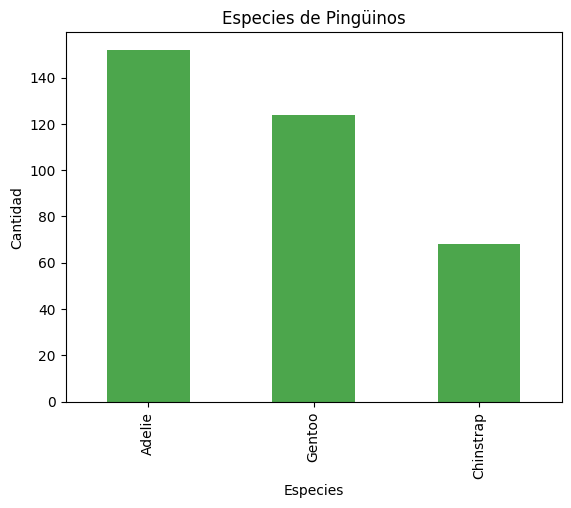

In [8]:
especies = pinguinos['species'].value_counts()
print(especies)

plt.figure()
especies.plot.bar(alpha=0.7,
                  color = 'g',
                  title='Especies de Pingüinos')
plt.xlabel('Especies')
plt.ylabel('Cantidad')
plt.show()

2. ¿Cuál es la distribución de pingüinos en cada isla? ¿Existe alguna especie predominante en cada isla? Visualiza la información en un gráfico de barras o pastel.

Biscoe: 168
Dream: 124
Torgersen: 52


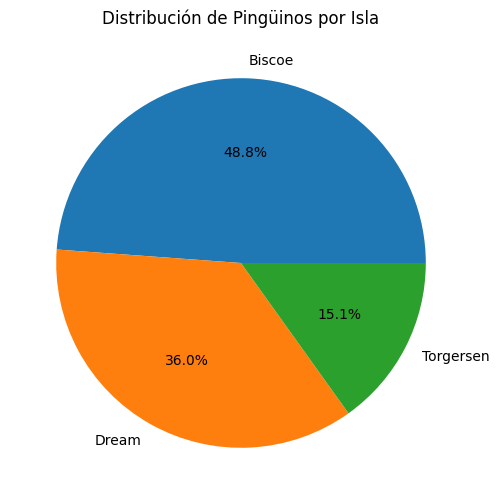

In [9]:
biscoe = (pinguinos['island'] == 'Biscoe').sum()
dream = (pinguinos['island'] == 'Dream').sum()
torgersen = (pinguinos['island'] == 'Torgersen').sum()

print('Biscoe:', biscoe)
print('Dream:', dream)
print('Torgersen:', torgersen)

plt.figure(figsize=(8, 6))
plt.pie([biscoe, dream, torgersen],
        labels=['Biscoe', 'Dream', 'Torgersen'],
        autopct='%1.1f%%')
plt.title('Distribución de Pingüinos por Isla')
plt.show()

3. ¿Hay valores nulos en el dataset? ¿Cómo podrían manejarse para evitar sesgos en el análisis? Representa los valores nulos en un mapa de calor.

In [12]:
dat_null = pinguinos.isnull().sum().sort_values(ascending = False)
dat_null

,0
sex,11
bill_depth_mm,2
bill_length_mm,2
flipper_length_mm,2
body_mass_g,2
island,0
species,0


In [29]:
# Comparado con el número de valores totales, los nulos son muy pocos, se pueden borrar
pg_clean = pinguinos.dropna(inplace=False)

Text(0.5, 1.0, 'Mapa de Calor de Valores Nulos')

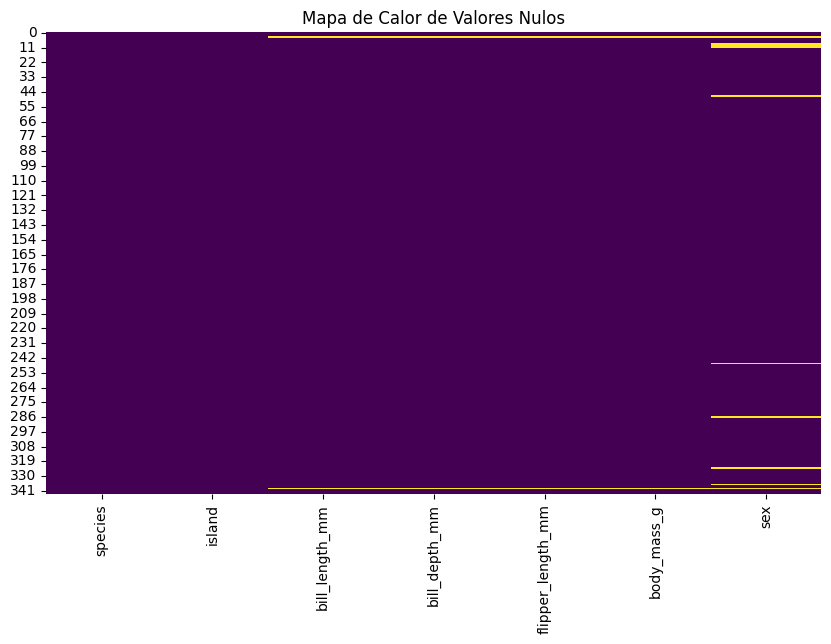

In [30]:
plt.figure(figsize=(10, 6))
sns.heatmap(pinguinos.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Valores Nulos')

4. ¿Cómo varía la masa corporal entre las diferentes especies? Utiliza un gráfico de violín o de cajas para comparar las distribuciones.

Text(0.5, 1.0, 'Relación entre la Masa corporal respecto a la Especie')

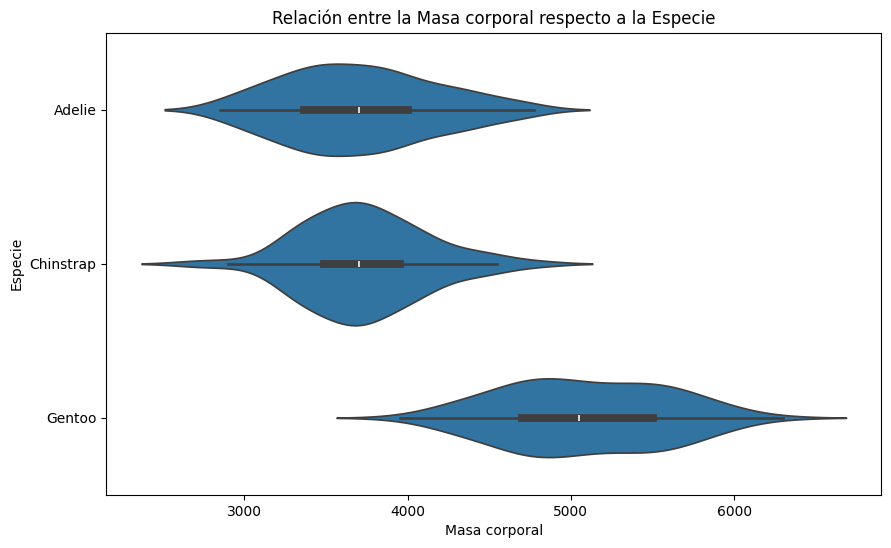

In [31]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=pg_clean, x="body_mass_g", y="species")

plt.xlabel("Masa corporal")
plt.ylabel("Especie")
plt.title("Relación entre la Masa corporal respecto a la Especie")

5. ¿Existe una correlación entre la longitud de la aleta y la masa corporal? Representa la relación en un gráfico de dispersión con una línea de tendencia.

Text(0.5, 1.0, 'Relación entre la Masa corporal y la Longitud de Aleta')

<Figure size 1000x600 with 0 Axes>

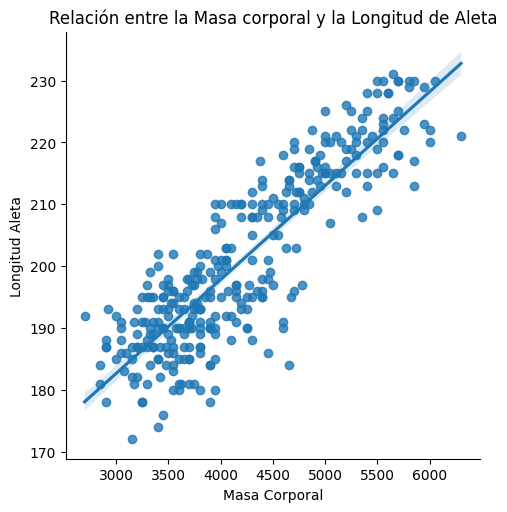

In [37]:
plt.figure(figsize=(10, 6))
sns.lmplot(data=pg_clean, x="body_mass_g", y="flipper_length_mm")

plt.xlabel("Masa Corporal")
plt.ylabel("Longitud Aleta")
plt.title("Relación entre la Masa corporal y la Longitud de Aleta")

6. ¿Los pingüinos machos y hembras presentan diferencias en la masa corporal? Justifica tu respuesta utilizando un gráfico de cajas.

Text(0.5, 1.0, 'Relación de la Masa Corporal para cada Sexo')

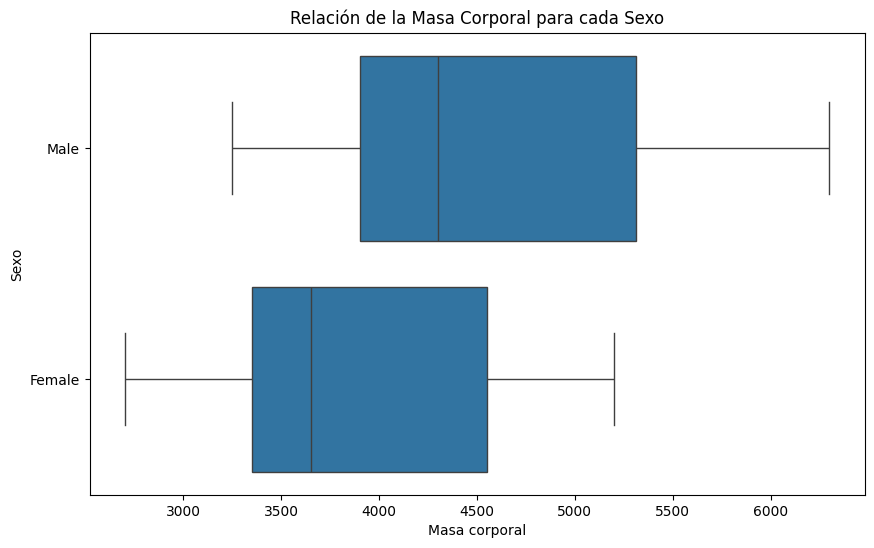

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=pg_clean, x="body_mass_g", y="sex")

plt.xlabel("Masa corporal")
plt.ylabel("Sexo")
plt.title("Relación de la Masa Corporal para cada Sexo")

7. ¿Cuál de las tres especies tiene los picos más largos? Representa la distribución de esta variable con un histograma o un gráfico de cajas.

Text(0.5, 1.0, 'Longitud del pico para cada Especie')

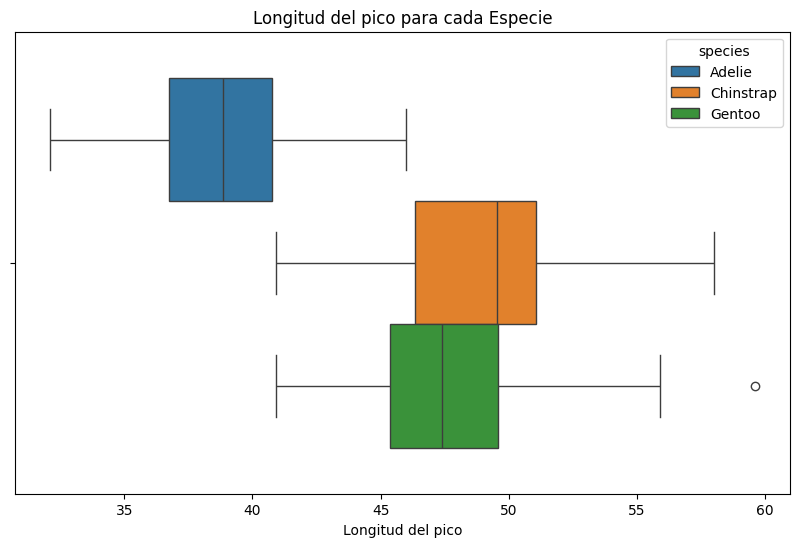

In [45]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=pg_clean, x="bill_length_mm", hue="species")

plt.xlabel("Longitud del pico")
plt.title("Longitud del pico para cada Especie")

8. ¿Podemos encontrar alguna relación entre la longitud del pico y la profundidad del mismo? Representa la relación en un gráfico de dispersión.

Text(0.5, 1.0, 'Relación entre la Longitud y Profundidad del Pico')

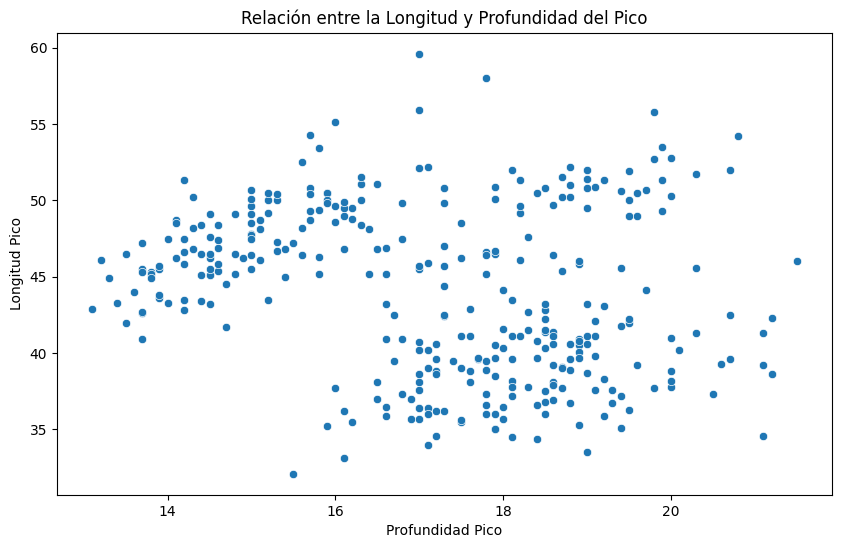

In [52]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pg_clean, y="bill_length_mm", x="bill_depth_mm")

plt.ylabel("Longitud Pico")
plt.xlabel("Profundidad Pico")
plt.title("Relación entre la Longitud y Profundidad del Pico")

9. ¿Cómo podrías identificar posibles valores atípicos en el dataset? Usa un boxplot para detectar valores atípicos en una variable de tu elección.

Text(0.5, 1.0, 'Longitud de Aleta para cada Especie')

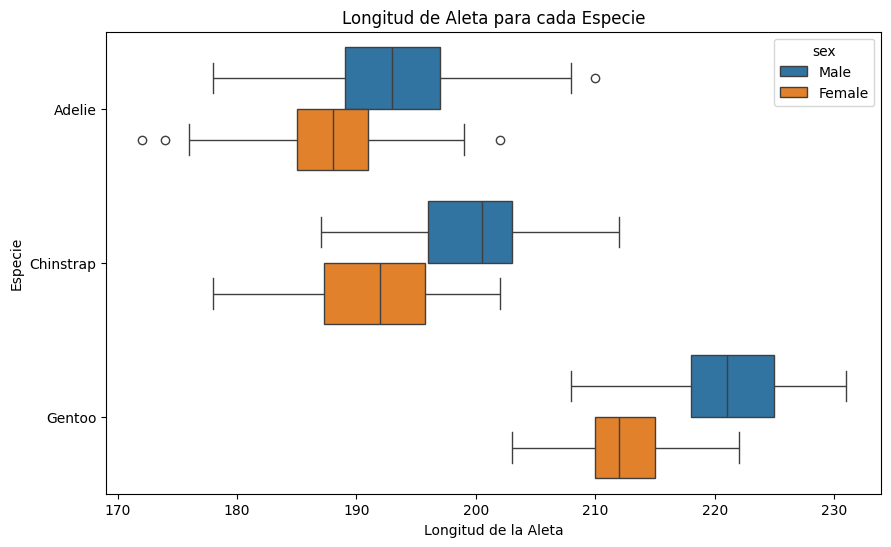

In [60]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=pg_clean, x="flipper_length_mm", y="species", hue="sex")

plt.xlabel("Longitud de la Aleta")
plt.ylabel("Especie")
plt.title("Longitud de Aleta para cada Especie")

10. ¿Qué otro tipo de análisis exploratorio podrías realizar con estos datos para extraer más información? Proponlo y visualízalo mediante gráficos adecuados.

Text(0.5, 1.0, 'Masa corporal para cada Especie')

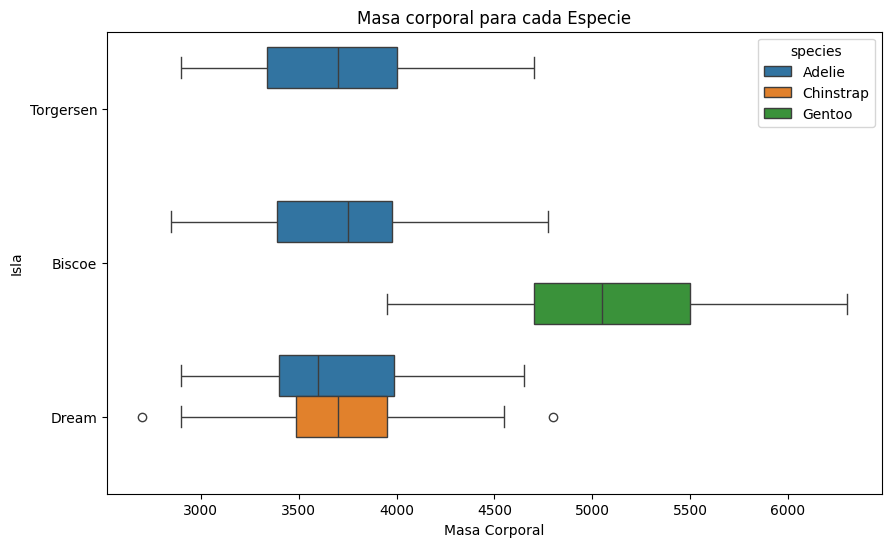

In [63]:
#analizar la relación entre la especie y la masa corporal, para cada isla
plt.figure(figsize=(10, 6))
sns.boxplot(data=pg_clean, x="body_mass_g", y="island", hue="species")

plt.xlabel("Masa Corporal")
plt.ylabel("Isla")
plt.title("Masa corporal para cada Especie")

Text(0.5, 1.0, 'Relación entre la Longitud y Profundidad del Pico')

<Figure size 1000x600 with 0 Axes>

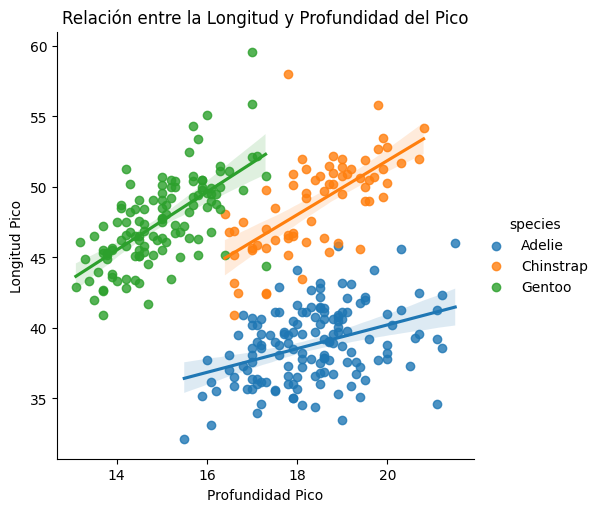

In [65]:
#relación entre la longitud del pico y su profundidad separado por especies
plt.figure(figsize=(10, 6))
sns.lmplot(data=pg_clean, y="bill_length_mm", x="bill_depth_mm", hue="species")

plt.ylabel("Longitud Pico")
plt.xlabel("Profundidad Pico")
plt.title("Relación entre la Longitud y Profundidad del Pico")

---

## **Actividad Final**
Responde las siguientes preguntas en un informe corto:
1. ¿Cuáles son los hallazgos más importantes de este análisis?
2. ¿Cómo mejorarías la limpieza y preparación de los datos?
3. ¿Qué otros análisis o visualizaciones podrías realizar para obtener más información?

#1)
-La especie Adelie es la más abundante y es la única presente en las 3 islas, mientras que las otras dos parecen ser nativas

-La isla Biscoe es la más habitada

-La longitud de la aleta y la masa corporal son directamente proporcionales, por tanto hay relación entre el peso y el tamaño del pinguino, se infiere que el pinguino Gentoo es la más grande.

-A manera general los pinguinos machos son mas pesados que las hembras, por tanto se infieren que son más grandes

-La relación entre la longitud y profundidad del pico parece existir solo cuando se separan los datos por especie, donde la relación es directamente proporcional

#2)
Se eliminaron los datos nulos dado que estos eran pocos en comparación con el total.

Se evidenciaron pocos datos atípicos en los graficos de caja por lo que no debería representar una afectación en el análisis.

#3)
Analizar la relación entre la masa corporal de las especies en cada isla puede dar información sobre las condiciones de la misma, como abundancia de comida que conllevaría a una mayor población y más especies.

También ayuda a analizar la adaptabilidad de las especies al visualizar su presencia en varias islas como es el caso de Adelie.
